## Generate outputs

Given that you have already run the Ingest and Run notebooks, this notebook takes the outputs of Run (the allpixels and allfires dataframes) and genarates the archival output files.

What we want out of this notebook is:
 - a snapshot of all the fires at a given t
 - a timeseries of each fire across time

In [1]:
import os
import datetime
import pandas as pd
import geopandas as gpd

from fireatlas import FireTime, FireObj, postprocess
from fireatlas.utils import timed

region = ['Quebec_PostHoc_redo_post_pull',]  # note you don't need the shape in here, just the name
tst = [2023, 4, 30, 'AM']
ted = [2023, 9, 15, 'PM']

2025-03-27 17:25:33,782 - fireatlas.FireLog - INFO - logger initialized!


## Read from disk

Since we want to use precisely the files that we just created in the Run notebook. We will set the `location` to "local".

In [2]:
allpixels = postprocess.read_allpixels(tst, ted, region, location="local")

2025-03-27 17:25:35,951 - fireatlas.FireLog - INFO - func:read_allpixels took: 1.66 sec


In [3]:
allfires_gdf = postprocess.read_allfires_gdf(tst, ted, region, location="local")

2025-03-27 17:25:36,502 - fireatlas.FireLog - INFO - func:read_allfires_gdf took: 547.03 ms


## Write snapshots

Write each geometry object into its own flatgeobuf file within a subdirectory.

In [4]:
# %%time
# postprocess.save_snapshots(allfires_gdf, region, tst, ted)

## Write large fires

Start by getting a list containing all the fireIDs for the large fires in the allfires geodataframe.

In [5]:
large_fires = postprocess.find_largefires(allfires_gdf)

2025-03-27 17:25:36,518 - fireatlas.FireLog - INFO - func:find_largefires took: 6.90 ms


In [6]:
large_fires
lf_df = pd.DataFrame({"lf_ids":large_fires})

First we'll use the `allpixels` object to create the `nplist` layer

In [7]:
# postprocess.save_large_fires_nplist(allpixels, region, large_fires, tst)

The rest of the layers will be created directly from the `allfires_gdf`.

In [8]:
# postprocess.save_large_fires_layers(allfires_gdf, region, large_fires, tst, ted)

In [9]:
### Test if 226 has fline issue in raw files

combo_v3fline = gpd.read_file("/home/jovyan/fireatlast_nrt/fireatlas/data/FEDSoutput-v3/Quebec_V3/2023/CombinedLargefire/20230915PM/lf_fireline.fgb", engine="pyogrio")
combo_newfline = gpd.read_file("/home/jovyan/fireatlast_nrt/fireatlas/data/FEDSoutput-v3/Quebec_PostHoc_redo_post_pull/2023/CombinedLargefire/20230915PM/lf_fireline.fgb", engine="pyogrio")
combo_v3 = gpd.read_file("/home/jovyan/fireatlast_nrt/fireatlas/data/FEDSoutput-v3/Quebec_V3/2023/CombinedLargefire/20230915PM/lf_perimeter.fgb", engine="pyogrio")

combo_new = gpd.read_file("/home/jovyan/fireatlast_nrt/fireatlas/data/FEDSoutput-v3/Quebec_PostHoc_redo_post_pull/2023/CombinedLargefire/20230915PM/lf_perimeter.fgb", engine="pyogrio")

In [10]:
import lonboard as lb

In [11]:
lb.viz(combo_v3fline[(combo_v3fline.mergeid == 226.0) & (combo_v3fline.t == "2023-06-02T12:00:00")])


### This is in Quebec V3 data in the combined data. 

/srv/conda/envs/notebook/lib/python3.12/site-packages/lonboard/_geoarrow/ops/reproject.py:107: UserWarning: Input being reprojected to EPSG:4326 CRS.
Lonboard is only able to render data in EPSG:4326 projection.
  warnings.warn(


Map(basemap_style=<CartoBasemap.DarkMatter: 'https://basemaps.cartocdn.com/gl/dark-matter-gl-style/style.json'…

In [12]:
lb.viz(combo_newfline[(combo_newfline.mergeid == 226.0) & (combo_newfline.t == "2023-06-02T12:00:00")])


/srv/conda/envs/notebook/lib/python3.12/site-packages/lonboard/_geoarrow/ops/reproject.py:107: UserWarning: Input being reprojected to EPSG:4326 CRS.
Lonboard is only able to render data in EPSG:4326 projection.
  warnings.warn(


Map(basemap_style=<CartoBasemap.DarkMatter: 'https://basemaps.cartocdn.com/gl/dark-matter-gl-style/style.json'…

In [13]:
##Check if in raw data

lf_fline = gpd.read_file("/home/jovyan/fireatlast_nrt/fireatlas/data/FEDSoutput-v3/Quebec_V3/2023/Largefire/226/fireline.fgb", engine="pyogrio")

lf = gpd.read_file("/home/jovyan/fireatlast_nrt/fireatlas/data/FEDSoutput-v3/Quebec_V3/2023/Largefire/226/perimeter.fgb", engine="pyogrio")

In [14]:
lb.viz(lf_fline[(lf_fline.t == "2023-06-02T00:00:00")])

/srv/conda/envs/notebook/lib/python3.12/site-packages/lonboard/_geoarrow/ops/reproject.py:107: UserWarning: Input being reprojected to EPSG:4326 CRS.
Lonboard is only able to render data in EPSG:4326 projection.
  warnings.warn(


Map(basemap_style=<CartoBasemap.DarkMatter: 'https://basemaps.cartocdn.com/gl/dark-matter-gl-style/style.json'…

In [15]:
lb.viz(lf_fline[(lf_fline.t == "2023-06-02T12:00:00")])

/srv/conda/envs/notebook/lib/python3.12/site-packages/lonboard/_geoarrow/ops/reproject.py:107: UserWarning: Input being reprojected to EPSG:4326 CRS.
Lonboard is only able to render data in EPSG:4326 projection.
  warnings.warn(


Map(basemap_style=<CartoBasemap.DarkMatter: 'https://basemaps.cartocdn.com/gl/dark-matter-gl-style/style.json'…

In [16]:
lb.viz(lf_fline[(lf_fline.t == "2023-06-03T00:00:00")])

/srv/conda/envs/notebook/lib/python3.12/site-packages/lonboard/_geoarrow/ops/reproject.py:107: UserWarning: Input being reprojected to EPSG:4326 CRS.
Lonboard is only able to render data in EPSG:4326 projection.
  warnings.warn(


Map(basemap_style=<CartoBasemap.DarkMatter: 'https://basemaps.cartocdn.com/gl/dark-matter-gl-style/style.json'…

In [17]:
fids = allfires_gdf[allfires_gdf.mergeid == 226].xs('2023-06-02 12:00:00', level='t').index
fids_pre = allfires_gdf[allfires_gdf.mergeid == 226].xs('2023-06-02 00:00:00', level='t').index

In [18]:
fids = fids.values
fids_pre = fids_pre.values

In [19]:
fids

array([226, 233, 236, 261])

In [20]:
fids_pre

array([226, 233, 236, 259, 260, 261, 284, 285, 286, 287, 296])

In [21]:
allfires_gdf[allfires_gdf.mergeid == 226].xs('2023-06-02 00:00:00', level='t')

,mergeid,invalid,ftype,n_pixels,n_newpixels,farea,fperim,flinelen,duration,pixden,meanFRP,t_st,t_ed,hull,fline,nfp
fireID,,,,,,,,,,,,,,,,
226,226,False,0,59,24,14.519858,15.407452,9.264184,1.0,4.063401,0.897500,2023-06-01 00:00:00,2023-06-02,"POLYGON ((3916345.812 1029700.760, 3915697.743...","MULTILINESTRING ((3916204.203 1029819.451, 391...","MULTIPOINT ((3919909.334 1032895.160), (391954..."
233,226,False,0,183,165,26.222351,31.962962,29.505020,0.5,6.978779,1.437758,2023-06-01 12:00:00,2023-06-02,"POLYGON ((3917480.284 1026319.824, 3917465.504...","MULTILINESTRING ((3917480.284 1026319.824, 391...","MULTIPOINT ((3924269.923 1029138.871), (392427..."
236,226,False,0,41,18,5.621303,11.344261,7.114364,0.5,7.293683,1.090556,2023-06-01 12:00:00,2023-06-02,"POLYGON ((3903520.836 1030077.843, 3903536.413...","MULTILINESTRING ((3903520.836 1030077.843, 390...","MULTIPOINT ((3905687.210 1026103.910), (390496..."
259,226,False,0,12,12,1.622358,5.161005,5.161005,0.0,7.396640,0.990000,2023-06-02 00:00:00,2023-06-02,"POLYGON ((3925822.755 1027841.811, 3925817.023...","LINESTRING (3925822.755 1027841.811, 3925817.0...","MULTIPOINT ((3925469.410 1027833.879), (392575..."
260,226,True,0,0,0,0.524587,2.875582,2.875582,0.0,0.000000,NaN,2023-06-02 00:00:00,2023-06-02,"POLYGON ((3923844.795 1028464.837, 3923830.798...","LINESTRING (3923844.795 1028464.837, 3923830.7...",MULTIPOINT EMPTY
261,226,False,0,18,18,3.965399,8.062329,7.048583,0.0,4.539266,1.082222,2023-06-02 00:00:00,2023-06-02,"POLYGON ((3907020.434 1025414.689, 3907007.517...","MULTILINESTRING ((3907020.434 1025414.689, 390...","MULTIPOINT ((3908389.829 1025028.271), (390856..."
284,226,True,0,0,0,0.270985,1.954819,1.954819,0.0,0.000000,NaN,2023-06-02 00:00:00,2023-06-02,"POLYGON ((3925014.683 1029276.971, 3924996.485...","LINESTRING (3925014.683 1029276.971, 3924996.4...",MULTIPOINT EMPTY
285,226,True,0,0,0,0.422317,2.492479,2.492479,0.0,0.000000,NaN,2023-06-02 00:00:00,2023-06-02,"POLYGON ((3924450.568 1030065.818, 3924460.683...","LINESTRING (3924450.568 1030065.818, 3924460.6...",MULTIPOINT EMPTY
286,226,True,0,0,0,0.217105,1.743883,1.743883,0.0,0.000000,NaN,2023-06-02 00:00:00,2023-06-02,"POLYGON ((3908581.818 1026547.674, 3908550.536...","LINESTRING (3908581.818 1026547.674, 3908550.5...",MULTIPOINT EMPTY


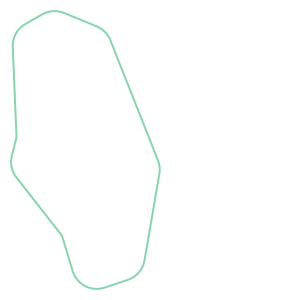

In [22]:
# allfires_gdf[allfires_gdf.mergeid == 226].xs('2023-06-02 12:00:00', level='t').loc[[226]][['mergeid', 'invalid', 'ftype', 'n_pixels', 'n_newpixels', 'farea',
#        'fperim', 'flinelen', 'duration', 'pixden', 'meanFRP', 't_st', 't_ed',
#        'fline']].fline.iloc[0]


allfires_gdf[allfires_gdf.mergeid == 226].xs('2023-06-02 00:00:00', level='t').loc[[259]][['mergeid', 'invalid', 'ftype', 'n_pixels', 'n_newpixels', 'farea',
       'fperim', 'flinelen', 'duration', 'pixden', 'meanFRP', 't_st', 't_ed',
       'fline']].fline.iloc[0]


#^ I checked all the flines in the ID and related IDS -- didn't see that weird cluster. Best is 233 seems to ling up partly with half of it?


## The time before is a fire 259. Duration 0.0 12 pixels, 

In [23]:
gdf = allfires_gdf.reset_index()

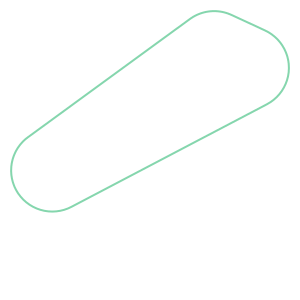

In [24]:
gdf[(gdf.mergeid == 226) | (gdf.fireID == 226)][['mergeid', 'invalid', 'ftype', 'n_pixels', 'n_newpixels', 'farea',
       'fperim', 'flinelen', 'duration', 'pixden', 'meanFRP', 't_st', 't_ed',
       'fline']].fline.iloc[0]

In [25]:
gdf

,fireID,t,mergeid,invalid,ftype,n_pixels,n_newpixels,farea,fperim,flinelen,duration,pixden,meanFRP,t_st,t_ed,hull,fline,nfp
0,1,2023-04-30 00:00:00,1,False,0,1,1,0.141000,1.177624,0.000000,0.0,7.092199,1.260000,2023-04-30 00:00:00,2023-04-30 00:00:00,"POLYGON ((4307229.944 1930650.905, 4307229.041...",None,MULTIPOINT ((4307042.444 1930650.905))
1,2,2023-04-30 12:00:00,2,False,0,3,3,0.209095,1.681798,1.681798,0.0,14.347557,3.653333,2023-04-30 12:00:00,2023-04-30 12:00:00,"POLYGON ((3684710.526 2531786.871, 3684628.221...","LINESTRING (3684710.526 2531786.871, 3684628.2...","MULTIPOINT ((3684624.473 2531972.688), (368448..."
2,3,2023-04-30 12:00:00,3,False,0,2,2,0.220539,2.355248,0.000000,0.0,9.068709,3.890000,2023-04-30 12:00:00,2023-04-30 12:00:00,"MULTIPOLYGON (((3886179.991 2641078.393, 38861...",None,"MULTIPOINT ((3885699.710 2641485.222), (388599..."
3,4,2023-04-30 12:00:00,4,False,0,3,3,0.183717,1.543475,1.543475,0.0,16.329457,2.506667,2023-04-30 12:00:00,2023-04-30 12:00:00,"POLYGON ((3929413.249 2363331.983, 3929306.028...","LINESTRING (3929413.249 2363331.983, 3929306.0...","MULTIPOINT ((3929184.256 2363382.982), (392929..."
4,5,2023-04-30 12:00:00,5,False,0,1,1,0.141000,1.177624,0.000000,0.0,7.092199,3.690000,2023-04-30 12:00:00,2023-04-30 12:00:00,"POLYGON ((3726306.481 2713869.691, 3726305.578...",None,MULTIPOINT ((3726118.981 2713869.691))
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9105,6,2023-09-15 12:00:00,6,False,1,551,1,1.654478,4.674882,0.000000,137.5,333.035645,2.930000,2023-05-01 00:00:00,2023-09-15 12:00:00,"POLYGON ((4848924.862 560817.964, 4848925.169 ...",None,MULTIPOINT ((4849709.136 560980.384))
9106,2647,2023-09-15 12:00:00,2647,False,0,29669,1,3080.539183,415.223047,0.000000,70.5,9.631106,4.860000,2023-07-07 00:00:00,2023-09-15 12:00:00,"MULTIPOLYGON (((3951533.299 811337.611, 395152...",None,MULTIPOINT ((3965605.573 867327.742))
9107,3692,2023-09-15 12:00:00,3692,False,0,9,1,0.625324,2.992850,0.000000,14.0,14.392548,2.490000,2023-09-01 12:00:00,2023-09-15 12:00:00,"POLYGON ((4677651.777 1280817.198, 4677633.606...",None,MULTIPOINT ((4677793.963 1281131.860))
9108,3756,2023-09-15 12:00:00,3756,False,0,1,1,0.141000,1.177624,0.000000,0.0,7.092199,2.440000,2023-09-15 12:00:00,2023-09-15 12:00:00,"POLYGON ((4698127.167 1291470.284, 4698126.264...",None,MULTIPOINT ((4697939.667 1291470.284))


In [30]:
#largefires

from fireatlas.utils import timed
from fireatlas.FireTypes import Region, TimeStep, Location
from fireatlas.FireTime import t2dt, t_generator
from fireatlas.FireGpkg_sfs import getdd as singlefire_getdd
from fireatlas.FireGpkg import getdd as snapshot_getdd
from fireatlas import settings

In [31]:
# """will save individual large fire artifacts as well as

# a combined perimeter, newpixel and fireline artifact of all large fires
# """
gdf = allfires_gdf.reset_index()

gdf[(gdf.fireID == 259) & (gdf.mergeid == 226)] ## Weird,seems like in the allfires_gdf object, there is a time for 6-02 00:00:00 and 6-03 00:00:00 but not  6-02 12:00:00 or 6-03 12:00:00


#lf_fline[lf_fline.t == "2023-06-03T12:00:00"] also has an internal fireline
#lf_fline[lf_fline.t == "2023-06-04T12:00:00"] until "2023-06-20T12:00:00" -- basically they just stick around

,fireID,t,mergeid,invalid,ftype,n_pixels,n_newpixels,farea,fperim,flinelen,duration,pixden,meanFRP,t_st,t_ed,hull,fline,nfp
599,259,2023-06-02,226,False,0,12,12,1.622358,5.161005,5.161005,0.0,7.39664,0.99,2023-06-02,2023-06-02,"POLYGON ((3925822.755 1027841.811, 3925817.023...","LINESTRING (3925822.755 1027841.811, 3925817.0...","MULTIPOINT ((3925469.410 1027833.879), (392575..."
752,259,2023-06-03,226,True,0,0,0,3.694304,7.465961,3.907359,1.0,0.00000,NaN,2023-06-02,2023-06-03,"POLYGON ((3925764.805 1027749.853, 3925759.434...","MULTILINESTRING ((3924890.248 1029643.914, 392...",MULTIPOINT EMPTY


In [32]:
gdf = gdf[gdf["fireID"].isin(large_fires) | gdf["mergeid"].isin(large_fires)] 

gdf[(gdf.fireID == 259) & (gdf.mergeid == 226)]

,fireID,t,mergeid,invalid,ftype,n_pixels,n_newpixels,farea,fperim,flinelen,duration,pixden,meanFRP,t_st,t_ed,hull,fline,nfp
599,259,2023-06-02,226,False,0,12,12,1.622358,5.161005,5.161005,0.0,7.39664,0.99,2023-06-02,2023-06-02,"POLYGON ((3925822.755 1027841.811, 3925817.023...","LINESTRING (3925822.755 1027841.811, 3925817.0...","MULTIPOINT ((3925469.410 1027833.879), (392575..."
752,259,2023-06-03,226,True,0,0,0,3.694304,7.465961,3.907359,1.0,0.00000,NaN,2023-06-02,2023-06-03,"POLYGON ((3925764.805 1027749.853, 3925759.434...","MULTILINESTRING ((3924890.248 1029643.914, 392...",MULTIPOINT EMPTY


In [34]:
# forward fill any timesteps that are mising
gdf = fill_activefire_rows(gdf, ted)

gdf[(gdf.fireID == 259) & (gdf.mergeid == 226)]

,fireID,t,mergeid,invalid,ftype,n_pixels,n_newpixels,farea,fperim,flinelen,duration,pixden,meanFRP,t_st,t_ed,hull,fline,nfp
599,259.0,2023-06-02 00:00:00,226,False,0,12,12,1.622358,5.161005,5.161005,0.0,7.39664,0.99,2023-06-02,2023-06-02,"POLYGON ((3925822.755 1027841.811, 3925817.023...","LINESTRING (3925822.755 1027841.811, 3925817.0...","MULTIPOINT ((3925469.410 1027833.879), (392575..."
0,259.0,2023-06-02 12:00:00,226,False,0,12,0,1.622358,5.161005,5.161005,0.0,7.39664,NaN,2023-06-02,2023-06-02,"POLYGON ((3925822.755 1027841.811, 3925817.023...","LINESTRING (3925822.755 1027841.811, 3925817.0...",None
752,259.0,2023-06-03 00:00:00,226,True,0,0,0,3.694304,7.465961,3.907359,1.0,0.00000,NaN,2023-06-02,2023-06-03,"POLYGON ((3925764.805 1027749.853, 3925759.434...","MULTILINESTRING ((3924890.248 1029643.914, 392...",MULTIPOINT EMPTY


In [35]:
merge_needed = (gdf.mergeid != gdf.fireID) & (gdf.invalid == False)
gdf[((gdf.fireID == 259) & (gdf.mergeid == 226)) & merge_needed] ## Tentitive theory -- the fill-between rows happens before invalidated fires are removed so rows in between the valid and invalid rows are inserted artificially. 

,fireID,t,mergeid,invalid,ftype,n_pixels,n_newpixels,farea,fperim,flinelen,duration,pixden,meanFRP,t_st,t_ed,hull,fline,nfp
599,259.0,2023-06-02 00:00:00,226,False,0,12,12,1.622358,5.161005,5.161005,0.0,7.39664,0.99,2023-06-02,2023-06-02,"POLYGON ((3925822.755 1027841.811, 3925817.023...","LINESTRING (3925822.755 1027841.811, 3925817.0...","MULTIPOINT ((3925469.410 1027833.879), (392575..."
0,259.0,2023-06-02 12:00:00,226,False,0,12,0,1.622358,5.161005,5.161005,0.0,7.39664,NaN,2023-06-02,2023-06-02,"POLYGON ((3925822.755 1027841.811, 3925817.023...","LINESTRING (3925822.755 1027841.811, 3925817.0...",None


In [36]:
print(f"{merge_needed.sum()} rows that potentially need a merge")

# we'll set the "fireID" to "mergeid" in those spots
gdf.loc[merge_needed, "fireID"] = gdf.loc[merge_needed, "mergeid"]



20539 rows that potentially need a merge


In [37]:
def merge_and_save_fire(data, fid):
    # merge any rows that have the same t
    if data.t.duplicated().any():
        data = merge_rows(data, fid)

    # save off single large fire artifacts
    save_fire_layers(data, region, int(fid), tst)
    
    # accumulate each fid for combined large fires
    return data

futures = []
processed_gdfs = []
for fid, data in gdf[gdf["fireID"].isin(large_fires)].groupby("fireID"):
    if client:
        futures.append(client.submit(merge_and_save_fire, data, fid))
    else:
        processed_gdfs.append(merge_and_save_fire(data, fid))
if futures:
    processed_gdfs = client.gather(futures)

# save off all large fire artifacts
if len(processed_gdfs) != 0:
    all_gdfs = gpd.GeoDataFrame(pd.concat(processed_gdfs, ignore_index=True))
    save_combined_large_fire_layers(all_gdfs, tst, ted, region)

NameError: name 'client' is not defined

In [ ]:
def save_large_fires_layers(allfires_gdf, region, large_fires, tst, ted, client=None):
    """will save individual large fire artifacts as well as

    a combined perimeter, newpixel and fireline artifact of all large fires
    """
    gdf = allfires_gdf.reset_index()

    gdf = gdf[gdf["fireID"].isin(large_fires) | gdf["mergeid"].isin(large_fires)]
    
    # forward fill any timesteps that are mising
    gdf = fill_activefire_rows(gdf, ted)
    
    merge_needed = (gdf.mergeid != gdf.fireID) & (gdf.invalid == False)
    print(f"{merge_needed.sum()} rows that potentially need a merge")

    # we'll set the "fireID" to "mergeid" in those spots
    gdf.loc[merge_needed, "fireID"] = gdf.loc[merge_needed, "mergeid"]

    def merge_and_save_fire(data, fid):
        # merge any rows that have the same t
        if data.t.duplicated().any():
            data = merge_rows(data, fid)

        # save off single large fire artifacts
        save_fire_layers(data, region, int(fid), tst)
        
        # accumulate each fid for combined large fires
        return data

    futures = []
    processed_gdfs = []
    for fid, data in gdf[gdf["fireID"].isin(large_fires)].groupby("fireID"):
        if client:
            futures.append(client.submit(merge_and_save_fire, data, fid))
        else:
            processed_gdfs.append(merge_and_save_fire(data, fid))
    if futures:
        processed_gdfs = client.gather(futures)

    # save off all large fire artifacts
    if len(processed_gdfs) != 0:
        all_gdfs = gpd.GeoDataFrame(pd.concat(processed_gdfs, ignore_index=True))
        save_combined_large_fire_layers(all_gdfs, tst, ted, region)

In [ ]:
dd = singlefire_getdd("all")

In [ ]:
# if allfires_gdf.index.names == ['fireID', 't']:
#     gdf = allfires_gdf.reset_index()
# else:
#     gdf = allfires_gdf

In [ ]:
dt = t2dt(ted)

In [ ]:
all_new_rows = []

for fid, allfires_gdf_fid in gdf[gdf.fireID == 259].groupby("fireID"):
    # print(fid)
    # print(allfires_gdf_fid)
    d = allfires_gdf_fid.set_index("t")
    
    # set last timestep so we fill after the fire has stopped burning
    if not d.iloc[-1]["invalid"]:
        print("entering loop")
        last_t = d.index[-1]
        if last_t != dt:
            last_t = min(last_t + datetime.timedelta(days=settings.maxoffdays), dt)
            d.loc[last_t] = None

    ffilled = d.resample("12H").ffill(limit=settings.limoffdays*2).dropna(how="all")

    # get all the rows that are new
    new_rows = ffilled[~ffilled.index.isin(d.index)]

    # set values that should not be forward filled.
    new_rows.loc[:,["n_newpixels", "meanFRP", "nfp"]] = 0, None, None
    
    all_new_rows.append(new_rows.reset_index())
    

In [38]:
        
output = pd.concat([gdf, *all_new_rows]).sort_values(["t", "fireID"])
for k, tp in dd.items():
    output[k] = output[k].astype(tp)

NameError: name 'all_new_rows' is not defined

In [33]:
def fill_activefire_rows(allfires_gdf, ted):
    """For a subset of allfires data, add any rows where a fire is still
    active, but is not burning.
    """
    dd = singlefire_getdd("all")
    
    if allfires_gdf.index.names == ['fireID', 't']:
        gdf = allfires_gdf.reset_index()
    else:
        gdf = allfires_gdf

    dt = t2dt(ted)
    all_new_rows = []
    for fid, allfires_gdf_fid in gdf.groupby("fireID"):
        d = allfires_gdf_fid.set_index("t")
        
        # set last timestep so we fill after the fire has stopped burning
        if not d.iloc[-1]["invalid"]:
            last_t = d.index[-1]
            if last_t != dt:
                last_t = min(last_t + datetime.timedelta(days=settings.maxoffdays), dt)
                d.loc[last_t] = None

        ffilled = d.resample("12H").ffill(limit=settings.limoffdays*2).dropna(how="all")

        # get all the rows that are new
        new_rows = ffilled[~ffilled.index.isin(d.index)]

        # set values that should not be forward filled.
        new_rows.loc[:,["n_newpixels", "meanFRP", "nfp"]] = 0, None, None
        
        all_new_rows.append(new_rows.reset_index())
            
    output = pd.concat([gdf, *all_new_rows]).sort_values(["t", "fireID"])
    for k, tp in dd.items():
        output[k] = output[k].astype(tp)
    return output

In [39]:
### I now need to read in the NRT fires to check if there are examples of internal flines to check
import s3fs
s3 = s3fs.S3FileSystem(anon=False)
#my_pickle = pickle.loads(s3.open("maap-ops-workspace/shared/gsfc_landslides/FEDSoutput-s3-conus/CONUS_NRT_DPS/2023/Serialization/20231231AM_full.pkl"))

nrt_lf = gpd.read_file("s3://maap-ops-workspace/shared/gsfc_landslides/FEDSoutput-v3/CONUS/2025/CombinedLargefire/20250326PM/lf_perimeter.fgb")
nrt_fline = gpd.read_file("s3://maap-ops-workspace/shared/gsfc_landslides/FEDSoutput-v3/CONUS/2025/CombinedLargefire/20250326PM/lf_fireline.fgb")

In [116]:
from shapely.geometry import MultiLineString, LineString
from shapely.geometry import Polygon, MultiPolygon
# def check_multipolygon_containment(gdf):
#     # Filter for MultiPolygon geometries
#     multipolygons = gdf[gdf.geometry.type == 'MultiPolygon']
    
#     # Function to check if any polygon is within another in the same MultiPolygon
#     def has_internal_containment(multipolygon):
#         polygons = list(multipolygon.geoms)
#         for i, poly1 in enumerate(polygons):
#             print("i")
#             for j, poly2 in enumerate(polygons):
#                 print("j")
#                 if i != j and poly1.within(poly2):
#                     return True
#         return False
    
#     # Apply the check to each MultiPolygon
#     multipolygons['has_internal_containment'] = multipolygons.geometry.apply(has_internal_containment)
#     return multipolygons
#     #return multipolygons[multipolygons['has_internal_containment']]



def check_multilinestring_containment(gdf, gdf_perimeter):
    # Filter for MultiLineString geometries
    multilinestrings = gdf[gdf.geometry.type == 'MultiLineString']
    
    # Function to check if any linestring is within another in the same MultiLineString
    def has_internal_containment(multilinestring):
        linestrings = list(multilinestring.geoms)
        for i, line1 in enumerate(linestrings):
            for j, line2 in enumerate(linestrings):
                if i != j and line1.within(line2):
                    return True
        return False
    
    # Apply the check to each MultiLineString
    multilinestrings['has_internal_containment'] = multilinestrings.geometry.apply(has_internal_containment)
    
    return multilinestrings[multilinestrings['has_internal_containment']]


In [117]:
#check_multipolygon_containment(lf_fline[lf_fline.t == "2023-06-02T12:00:00"])

In [129]:
# def check_multilinestring_containment(gdf, gdf_perimeter):
#     #multilinestrings = gdf[gdf.geometry.type == 'MultiLineString']


def coerce_to_multipolygon(geom):
    if isinstance(geom, Polygon):
        return MultiPolygon([geom])
    elif isinstance(geom, MultiPolygon):
        return geom
    else:
        return geom

def has_internal_containment(multilinestring, multipolygons):
    linestrings = list(multilinestring.geoms)
    multipolygons = coerce_to_multipolygon(multipolygons) ### Need to cooerce into a multi polygon
    polygons = list(multipolygons.geoms)
    #print(len(polygons))
    #print(len(linestrings))
    is_in = []
    for i, line1 in enumerate(linestrings):
        #print("i")
        for j, line2 in enumerate(polygons):
            #print("j")
            #if i != j and line1.within(line2):
            if i != j and line1.within(line2):
                is_in.append(True)
            else:
                is_in.append(False)
    return any(is_in)
    # return(multilinestrings)

#lf_fline[lf_fline.t == "2023-06-02T12:00:00"].geometry.intersects(lf[lf.t == "2023-06-02T12:00:00"].geometry)

tmp = has_internal_containment(lf_fline[lf_fline.t == "2023-06-02T12:00:00"].geometry.iloc[0], lf[lf.t == "2023-06-02T12:00:00"].geometry.iloc[0]) ### Should return true
print(tmp)

tmp = has_internal_containment(lf_fline[lf_fline.t == "2023-06-01T12:00:00"].geometry.iloc[0], lf[lf.t == "2023-06-01T12:00:00"].geometry.iloc[0]) ### Should return false
print(tmp)

tmp = has_internal_containment(lf_fline[lf_fline.t == "2023-06-20T12:00:00"].geometry.iloc[0], lf[lf.t == "2023-06-20T12:00:00"].geometry.iloc[0]) ### Should return true
print(tmp)

#check_multilinestring_containment(lf_fline[lf_fline.t == "2023-06-02T12:00:00"].geometry.iloc[0], lf[lf.t == "2023-06-02T12:00:00"].geometry.iloc[0])

True
False
True


In [134]:
#### 
import numpy as np

def find_internal_fline(gdf, gdf_polygon):
    for t in gdf.t.unique():
        for fid in gdf.fireID.unique():
            if(len(gdf[(gdf.t == t) & (gdf.fireID == fid)]) > 0):
                if (gdf[(gdf.t == t) & (gdf.fireID == fid)].geometry.iloc[0].type == 'MultiLineString'): # gdf.geometry.type == 'MultiLineString'
                    sm_gdf = gdf[(gdf.t == t) & (gdf.fireID == fid)].geometry.iloc[0]
                    sm_gdf_polygon = gdf_polygon[(gdf_polygon.t == t) & (gdf_polygon.fireID == fid)].geometry.iloc[0]
                    contain_bool = has_internal_containment(sm_gdf, sm_gdf_polygon)
                    if (np.isnan(contain_bool)):
                        print(f"fire ID {fid} |  t {t}")
                        break
                    gdf.loc[((gdf.t == t) & (gdf.fireID == fid)), "internal_fline"] =  contain_bool
                    gdf_polygon.loc[((gdf_polygon.t == t) & (gdf_polygon.fireID == fid)), "internal_fline"] =  contain_bool
                else:
                    gdf.loc[((gdf.t == t) & (gdf.fireID == fid)), "internal_fline"] =  False
                    gdf_polygon.loc[((gdf_polygon.t == t) & (gdf_polygon.fireID == fid)), "internal_fline"] =  False
            
                
lf_new = combo_new
lf_fline_new = combo_newfline



#find_internal_fline(lf_fline_new, lf_new)

In [135]:
foo = find_internal_fline(lf_fline_new, lf_new)

In [99]:
nrt_fline[nrt_fline.internal_fline].fireID.unique()

array([ 2425.,  6159., 12189., 19570., 22399.,  5873., 14574., 11610.,
       19887., 20424., 28299.,  6794.,  6795., 22418.,  5531., 18793.,
       18802.,  6803.,   932., 23487.,  6465., 13765., 13453., 28417.,
        1583.,  9756.,   190.,   191.,   193., 10865.,   162., 26178.,
       11730., 10590., 11703., 25061., 13958., 22546., 25620., 23954.,
       15704., 15724., 17434., 17406.,  5274.,   701.,   117., 18876.,
       28399., 16309., 21834.,  4402., 13397., 28420., 19574., 26585.,
        4287., 23181., 28215.,   195., 13199.,  7572., 27454., 17526.,
       17079., 25090., 15638., 30585., 28039., 13229., 15884., 13269.,
       18237., 18697., 13285., 23264., 15854., 30204., 16704., 29721.,
       13823., 30501., 25035., 16739., 15771., 17942., 17937., 18561.,
       30230., 17949., 14355., 30061., 17960., 17492., 17854., 13820.,
       13278., 25153., 17904., 13276., 24513., 20273., 17970., 15899.,
       22972., 15798., 14934.,  8006., 15062., 15588., 13785., 13032.,
      

In [95]:
#lb.viz(lf_fline_new[lf_fline_new.internal_fline & (lf_fline_new.mergeid == 1271) ])

lb.viz(lf_fline_new[(lf_fline_new.fireID == 15) & (lf_fline_new.t =='2023-08-01T00:00:00')])


/srv/conda/envs/notebook/lib/python3.12/site-packages/lonboard/_geoarrow/ops/reproject.py:107: UserWarning: Input being reprojected to EPSG:4326 CRS.
Lonboard is only able to render data in EPSG:4326 projection.
  warnings.warn(


Map(basemap_style=<CartoBasemap.DarkMatter: 'https://basemaps.cartocdn.com/gl/dark-matter-gl-style/style.json'…

In [73]:
lb.viz(lf_new.loc[[104.0]])

/srv/conda/envs/notebook/lib/python3.12/site-packages/lonboard/_geoarrow/ops/reproject.py:107: UserWarning: Input being reprojected to EPSG:4326 CRS.
Lonboard is only able to render data in EPSG:4326 projection.
  warnings.warn(


Map(basemap_style=<CartoBasemap.DarkMatter: 'https://basemaps.cartocdn.com/gl/dark-matter-gl-style/style.json'…

In [136]:
### ok! Looking for examples from NRT

find_internal_fline(nrt_fline, nrt_lf)



In [137]:
nrt_fline[nrt_fline.internal_fline].fireID.unique()

array([], dtype=float64)

In [102]:
nrt_fline = nrt_fline.to_crs(4326)

#219.0 seems to be a real error

fid =  219
row_mask = nrt_fline.internal_fline & (nrt_fline.fireID == fid)
t_max = nrt_fline[row_mask].t.max()
row_mask = nrt_fline.internal_fline & (nrt_fline.fireID == fid) & (nrt_fline.t == t_max)
lb.viz(nrt_fline[row_mask]) # 420, 12189, 28251, 22109 not really 

Map(basemap_style=<CartoBasemap.DarkMatter: 'https://basemaps.cartocdn.com/gl/dark-matter-gl-style/style.json'…

In [153]:
lb.viz(lf_fline_new[lf_fline_new.internal_fline & (lf_fline_new.t =='2023-06-07T12:00:00')])

/srv/conda/envs/notebook/lib/python3.12/site-packages/lonboard/_geoarrow/ops/reproject.py:107: UserWarning: Input being reprojected to EPSG:4326 CRS.
Lonboard is only able to render data in EPSG:4326 projection.
  warnings.warn(


Map(basemap_style=<CartoBasemap.DarkMatter: 'https://basemaps.cartocdn.com/gl/dark-matter-gl-style/style.json'…

In [ ]:
lf_fline_new[lf_fline_new.internal_fline & (lf_fline_new.t =='2023-06-07T12:00:00')]f